# Week 3 – Sales Exploratory Data Analysis

## Objective

Analyse sales performance using the validated and feature-engineered sales dataset.

The analysis focuses on:

- Sales trends
- Order performance
- Sales channels
- Branch performance
- Customer performance
- Product performance
- Sales distribution
- Monthly and yearly patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
sales = pd.read_csv(
    "/content/sales_features.csv"
)

print("Sales shape:", sales.shape)

display(sales.head())

Sales shape: (130402, 83)


,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total,customer_id,branch_id,order_date,delivery_date,order_status,payment_terms,total_order_value,total_gst_amount,grand_total,sales_channel,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price_product,margin_percentage,gst_rate_product,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level,safety_stock,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,customer_type,industry_segment,city,state,pincode,region,branch_id_customer,credit_limit,current_balance,payment_terms_customer,customer_since,last_purchase_date_customer,total_purchase_value,customer_rating,order_year,order_month,order_month_name,order_quarter,order_week,order_day,order_day_name,order_day_of_week,calculated_line_total,line_total_difference,quantity_log,unit_price_log,order_quantity,order_line_count,order_sales_value,unique_products,average_unit_price,gst_rate_calculated,gst_rate_difference,customer_total_sales,customer_total_orders,customer_total_quantity,customer_unique_products,product_total_sales,product_total_quantity,product_total_orders,product_unique_customers,customer_recency_days
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Wheel Rim WR-24,Undercarriage,Bulldozer,CAT,CAT D6R,8200,11300,37.8,28,24.00,70x25x25,steel,12,12,6,30,20,High,Medium,piece,8000,2024-02-20,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3,2022,5,May,2,21,24,Tuesday,1,214700,0,2.995732,9.332646,92,11,1720159.6,8,11300.0,28.0,3.552714e-15,87747724.2,48,3393,30,6.512705e+08,45027,3839,500,315
1,SO-990591,2,P026,2,310,18,620,111.6,731.6,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Grease Cartridge GC-5,Lubricants,All,Generic,All Models,180,310,72.2,18,0.45,25x6x6,synthetic,3,200,100,500,4,Low,High,cartridge,170,2020-04-02,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3,2022,5,May,2,21,24,Tuesday,1,620,0,1.098612,5.739793,92,11,1720159.6,8,310.0,18.0,0.000000e+00,87747724.2,48,3393,30,1.640394e+07,44844,3823,500,1734
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Grease Cartridge GC-5,Lubricants,All,Generic,All Models,180,310,72.2,18,0.45,25x6x6,synthetic,3,200,100,500,4,Low,High,cartridge,170,2020-04-02,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3,2022,5,May,2,21,24,Tuesday,1,930,0,1.386294,5.739793,92,11,1720159.6,8,310.0,18.0,0.000000e+00,87747724.2,48,3393,30,1.640394e+07,44844,3823,500,1734
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Seal Kit SK-15,Seals,Excavator,CAT,CAT 320D,950,1450,52.6,18,0.60,15x10x6,rubber,6,80,40,200,9,Medium,High,set,920,2022-12-19,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3,2022,5,May,2,21,24,Tuesday,1,13050,0,2.302585,7.280008,92,11,1720159.6,8,1450.0,18.0,0.000000e+00,87747724.2,48,3393,30,7.542259e+07,44081,3783,499,743
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Track Chain TC-45,Undercarriage,Bulldozer,Volvo,Volvo D6,32500,39800,22.5,28,210.00,180x40x35,steel,18,8,4,20,30,High,Low,set,32000,2020-06-18,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3,2022,5,May,2,21,24,Tuesday,1,119400,0,1.386294,10.591647,92,11,1720159.6,8,39800.0,28.0,3.552714e-15,87747724.2,48,3393,30,2.321773e+09,45575,3781,500,1657


Inspect Data

In [3]:
print("Shape:", sales.shape)

print("\nColumns:")
print(sales.columns.tolist())

print("\nData types:")
print(sales.dtypes)

print("\nMissing values:")
display(
    sales.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Shape: (130402, 83)

Columns:
['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price_product', 'margin_percentage', 'gst_rate_product', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom', 'last_purchase_price', 'last_purchase_date', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id_customer', 'credit_limit', 'current_balance', 'payment_terms_customer', 'customer_since', 'last_purchase_date_customer', 'total_purchase_value', 'customer_rating', 'order_year', 'order_month', 'order_month_name', '

,0
so_id,0
line_number,0
product_id,0
quantity,0
unit_price,0
gst_rate,0
line_total,0
gst_amount,0
line_grand_total,0
customer_id,0


Prepare Dates

In [4]:
sales['order_date'] = pd.to_datetime(
    sales['order_date'],
    errors='coerce'
)

sales['order_year'] = sales['order_date'].dt.year
sales['order_month'] = sales['order_date'].dt.month
sales['order_month_name'] = sales['order_date'].dt.month_name()
sales['order_quarter'] = sales['order_date'].dt.quarter

Overall Sales Summary

In [5]:
total_sales = sales['line_grand_total'].sum()

total_orders = sales['so_id'].nunique()

total_quantity = sales['quantity'].sum()

total_products = sales['product_id'].nunique()

total_customers = sales['customer_id'].nunique()

average_order_value = (
    total_sales / total_orders
    if total_orders > 0
    else 0
)

print("Total Sales:", f"{total_sales:,.2f}")
print("Total Orders:", f"{total_orders:,}")
print("Total Quantity Sold:", f"{total_quantity:,}")
print("Total Products:", f"{total_products:,}")
print("Total Customers:", f"{total_customers:,}")
print("Average Order Value:", f"{average_order_value:,.2f}")

Total Sales: 32,424,754,555.80
Total Orders: 20,000
Total Quantity Sold: 1,368,534
Total Products: 30
Total Customers: 500
Average Order Value: 1,621,237.73


Yearly Sales

In [6]:
yearly_sales = (
    sales.groupby('order_year')
    .agg(
        sales=('line_grand_total', 'sum'),
        orders=('so_id', 'nunique'),
        quantity=('quantity', 'sum')
    )
    .reset_index()
)

display(yearly_sales)

,order_year,sales,orders,quantity
0,2019,5.403206e+09,3336,227690
1,2020,5.503238e+09,3358,233662
2,2021,5.415991e+09,3365,230332
3,2022,5.411518e+09,3279,225035
4,2023,5.394009e+09,3346,226927
5,2024,5.296793e+09,3316,224888


Yearly Sales Chart

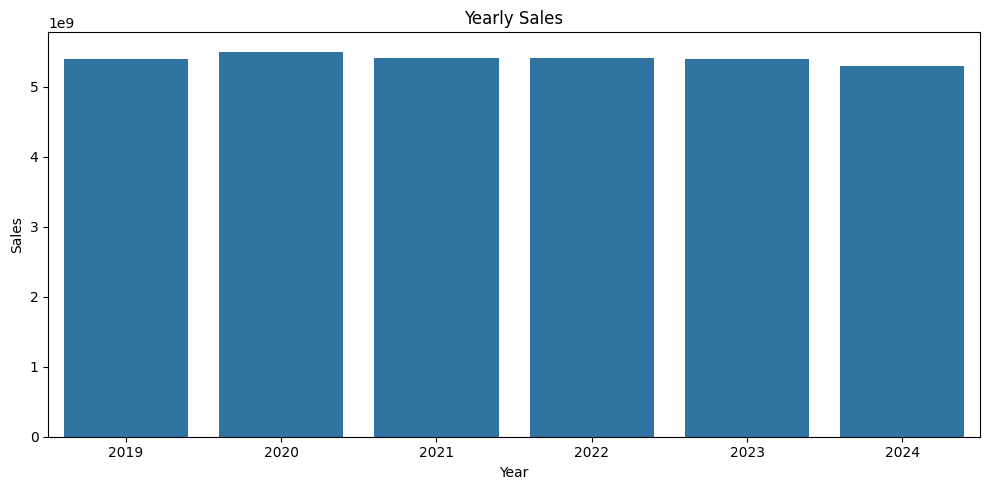

In [7]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly_sales,
    x='order_year',
    y='sales'
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Monthly Sales

In [8]:
monthly_sales = (
    sales.groupby(
        sales['order_date'].dt.to_period('M')
    )
    .agg(
        sales=('line_grand_total', 'sum'),
        orders=('so_id', 'nunique'),
        quantity=('quantity', 'sum')
    )
    .reset_index()
)

monthly_sales['order_date'] = (
    monthly_sales['order_date']
    .astype(str)
)

display(monthly_sales.head())

,order_date,sales,orders,quantity
0,2019-01,501079627.8,286,19023
1,2019-02,359469310.8,237,15213
2,2019-03,469342947.4,294,19796
3,2019-04,470149122.4,281,19672
4,2019-05,464091849.2,285,20130


Monthly Sales Trend

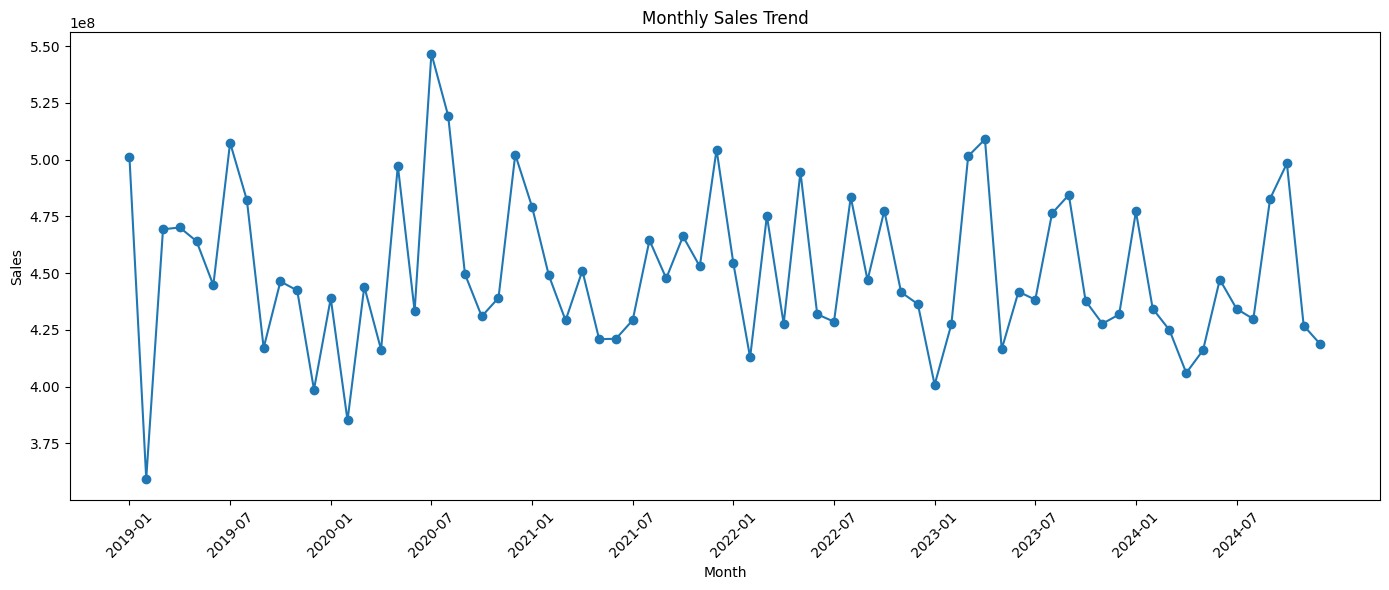

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['order_date'],
    monthly_sales['sales'],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

# Display a label every 6th month (index offset=0, step=6)
plt.gca().xaxis.set_major_locator(ticker.IndexLocator(base=6, offset=0))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Quarter

In [10]:
quarterly_sales = (
    sales.groupby(
        ['order_year', 'order_quarter']
    )['line_grand_total']
    .sum()
    .reset_index()
)

display(quarterly_sales)

,order_year,order_quarter,line_grand_total
0,2019,1,1.329892e+09
1,2019,2,1.378980e+09
2,2019,3,1.406813e+09
3,2019,4,1.287521e+09
4,2020,1,1.268186e+09
5,2020,2,1.346960e+09
6,2020,3,1.515699e+09
7,2020,4,1.372393e+09
8,2021,1,1.357531e+09
9,2021,2,1.293208e+09


Sales by Branch

In [11]:
if 'branch_id' in sales.columns:

    branch_sales = (
        sales.groupby('branch_id')
        .agg(
            sales=('line_grand_total', 'sum'),
            orders=('so_id', 'nunique'),
            quantity=('quantity', 'sum')
        )
        .sort_values(
            'sales',
            ascending=False
        )
        .reset_index()
    )

    display(branch_sales.head(10))

,branch_id,sales,orders,quantity
0,CHN001,6.615942e+09,4067,280446
1,KOL001,6.100494e+09,3794,256095
2,AHM001,5.616586e+09,3446,236347
3,DEL001,4.926515e+09,2953,204734
4,PUN001,4.766708e+09,2972,201749
5,HYD001,4.398510e+09,2768,189163


Branch Sales Chart

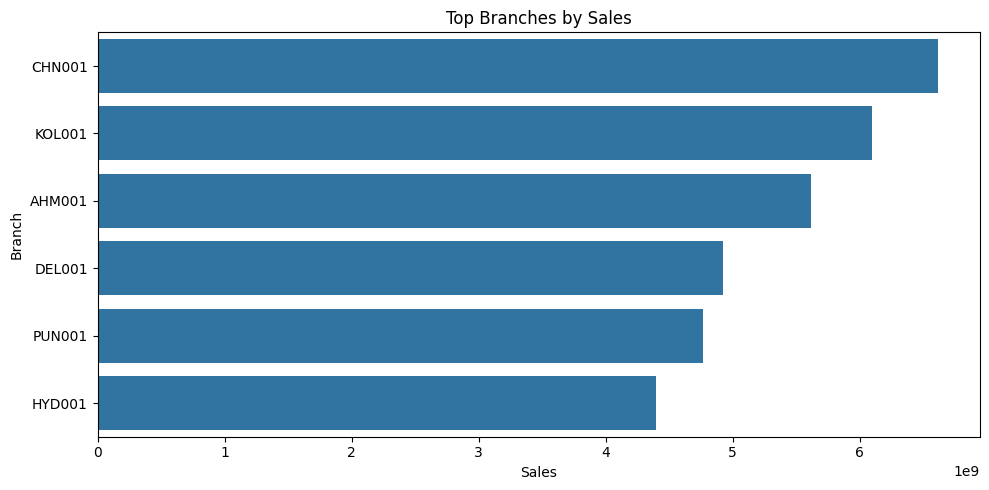

In [12]:
if 'branch_id' in sales.columns:

    top_branches = branch_sales.head(10)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=top_branches,
        x='sales',
        y='branch_id'
    )

    plt.title("Top Branches by Sales")
    plt.xlabel("Sales")
    plt.ylabel("Branch")

    plt.tight_layout()
    plt.show()

Sales by Channel

In [13]:
if 'sales_channel' in sales.columns:

    channel_sales = (
        sales.groupby('sales_channel')
        .agg(
            sales=('line_grand_total', 'sum'),
            orders=('so_id', 'nunique'),
            quantity=('quantity', 'sum')
        )
        .sort_values(
            'sales',
            ascending=False
        )
        .reset_index()
    )

    display(channel_sales)

,sales_channel,sales,orders,quantity
0,Field Sales,8.210171e+09,5036,346107
1,Counter Sale,8.172855e+09,5014,345148
2,Dealer Network,8.107783e+09,5028,342006
3,Online,7.933945e+09,4922,335273


Channel Sales Chart

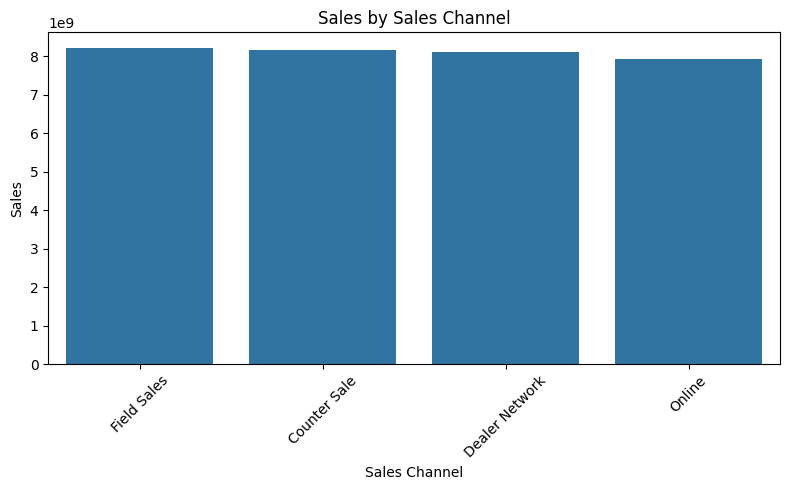

In [14]:
if 'sales_channel' in sales.columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=channel_sales,
        x='sales_channel',
        y='sales'
    )

    plt.title("Sales by Sales Channel")
    plt.xlabel("Sales Channel")
    plt.ylabel("Sales")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Top Products

In [15]:
top_products = (
    sales.groupby('product_id')
    .agg(
        sales=('line_grand_total', 'sum'),
        quantity=('quantity', 'sum'),
        orders=('so_id', 'nunique')
    )
    .sort_values(
        'sales',
        ascending=False
    )
    .reset_index()
)

display(top_products.head(10))

,product_id,sales,quantity,orders
0,P015,6.888215e+09,45222,3773
1,P014,4.813341e+09,45035,3838
2,P021,2.741782e+09,46364,3873
3,P019,2.341947e+09,45971,3849
4,P004,2.321773e+09,45575,3781
5,P010,2.097976e+09,46964,3933
6,P011,1.646709e+09,46612,3982
7,P001,1.423399e+09,45389,3854
8,P030,1.286585e+09,45897,3856
9,P022,9.911566e+08,45819,3892


Top Product Charts

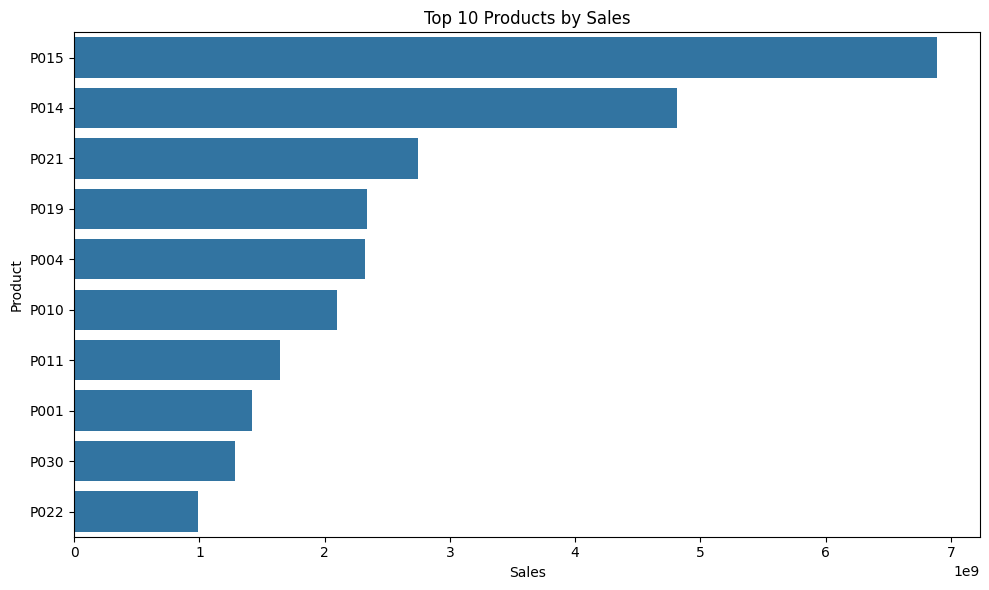

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products.head(10),
    x='sales',
    y='product_id'
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Top Customers

In [17]:
top_customers = (
    sales.groupby('customer_id')
    .agg(
        sales=('line_grand_total', 'sum'),
        orders=('so_id', 'nunique'),
        quantity=('quantity', 'sum')
    )
    .sort_values(
        'sales',
        ascending=False
    )
    .reset_index()
)

display(top_customers.head(10))

,customer_id,sales,orders,quantity
0,C0153,109360638.6,59,4256
1,C0483,108672502.0,53,3846
2,C0288,107119652.2,63,4626
3,C0495,105717422.2,52,3819
4,C0420,105420085.2,54,4133
5,C0240,104286776.8,50,3799
6,C0207,101737768.4,51,3583
7,C0342,100153639.6,44,3725
8,C0466,99913868.2,52,3880
9,C0359,99895983.4,52,3851


Sales Distribution

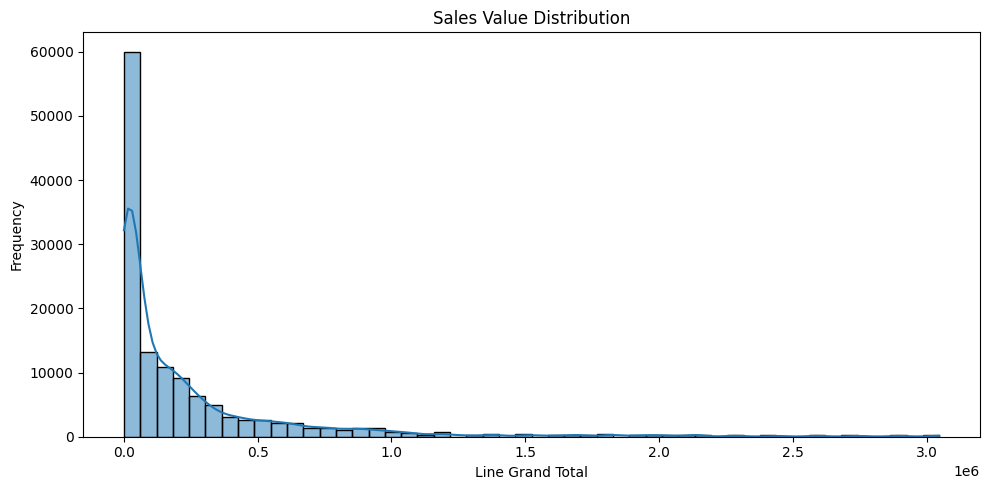

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sales['line_grand_total'],
    bins=50,
    kde=True
)

plt.title("Sales Value Distribution")
plt.xlabel("Line Grand Total")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Order Value Distribution

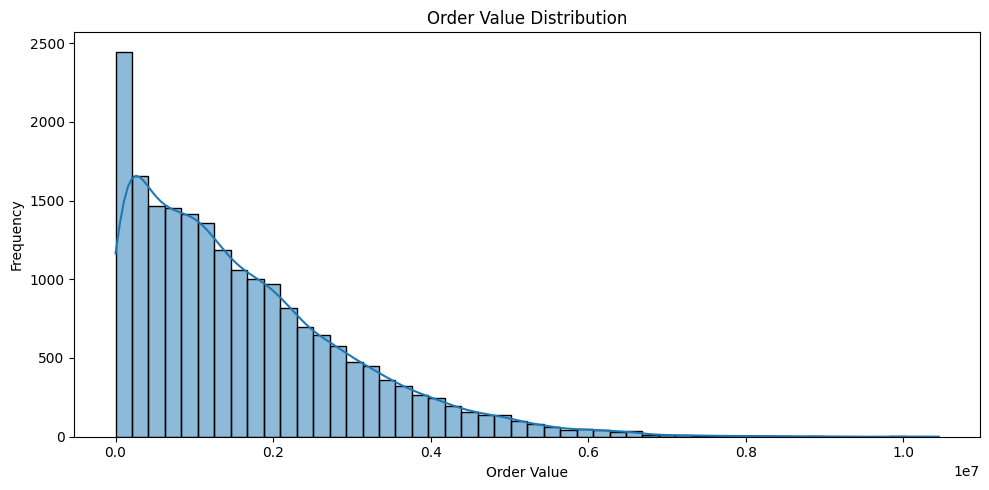

In [19]:
order_values = (
    sales.groupby('so_id')['line_grand_total']
    .sum()
    .reset_index(name='order_value')
)

plt.figure(figsize=(10, 5))

sns.histplot(
    order_values['order_value'],
    bins=50,
    kde=True
)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Sales EDA Summary

In [20]:
print("=" * 60)
print("SALES EDA SUMMARY")
print("=" * 60)

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: {average_order_value:,.2f}")

print("\nTop 5 Products:")
display(top_products.head(5))

print("\nTop 5 Customers:")
display(top_customers.head(5))

SALES EDA SUMMARY
Total Sales: 32,424,754,555.80
Total Orders: 20,000
Total Quantity: 1,368,534
Total Products: 30
Total Customers: 500
Average Order Value: 1,621,237.73

Top 5 Products:


,product_id,sales,quantity,orders
0,P015,6.888215e+09,45222,3773
1,P014,4.813341e+09,45035,3838
2,P021,2.741782e+09,46364,3873
3,P019,2.341947e+09,45971,3849
4,P004,2.321773e+09,45575,3781



Top 5 Customers:


,customer_id,sales,orders,quantity
0,C0153,109360638.6,59,4256
1,C0483,108672502.0,53,3846
2,C0288,107119652.2,63,4626
3,C0495,105717422.2,52,3819
4,C0420,105420085.2,54,4133
